In [21]:
import glob 
import xarray
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import seaborn as sns

In [ ]:
mon = 9
day = 15
file_pattern = 'curtain_tracks_Exp01/p3_2019-'
file_paths = [f'{mon:02}-{day:02}-03600_day1_track_MUSICAv0_7km_CAMP2Ex.nc', f'{mon:02}-{day+1:02}-03600_day2_track_MUSICAv0_7km_CAMP2Ex.nc']
full_file_paths = [file_pattern + file_path for file_path in file_paths]
ds = xarray.open_mfdataset(full_file_paths, combine='by_coords')
df = ds.to_dataframe().reset_index()
df['datetime'] = pd.to_datetime(df['datetime'])

df_orig = df
df = df[df['yco'] < 8.5]

df = df[['zco', 'bc_sp2','bc_mod']]
df = df.dropna()
bin_edges = np.arange(100, 8000, 75)

df['altitude_bins'] = pd.cut(df['zco'], bins=bin_edges)
grouped_mean_sp2_exp01 = df.groupby('altitude_bins')['bc_sp2'].mean()
grouped_med_sp2_exp01 = df.groupby('altitude_bins')['bc_sp2'].median()
grouped_std_sp2_exp01 = df.groupby('altitude_bins')['bc_sp2'].std()
grouped_mean_mod_exp01 = df.groupby('altitude_bins')['bc_mod'].mean()
grouped_std_mod_exp01 = df.groupby('altitude_bins')['bc_mod'].std()
grouped_med_mod_exp01 = df.groupby('altitude_bins')['bc_mod'].median()

bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2
bin_centers = bin_centers/1000

df_melted = df.melt(id_vars=['altitude_bins'], value_vars=['bc_sp2', 'bc_mod'], var_name='BC Type', value_name='BC Value')

df = df_orig
df = df[['zco', 'oa_ams','soa_mod', 'pom_mod']]
df = df.dropna()
df['altitude_bins'] = pd.cut(df['zco'], bins=bin_edges)
df['oa_mod'] = df['soa_mod'] + df['pom_mod']
grouped_mean_oa_ams_exp01 = df.groupby('altitude_bins')['oa_ams'].mean()
grouped_med_oa_ams_exp01 = df.groupby('altitude_bins')['oa_ams'].median()
grouped_std_oa_ams_exp01 = df.groupby('altitude_bins')['oa_ams'].std()

grouped_mean_oa_mod_exp01 = df.groupby('altitude_bins')['oa_mod'].mean()
grouped_std_oa_mod_exp01 = df.groupby('altitude_bins')['oa_mod'].std()
grouped_med_oa_mod_exp01 = df.groupby('altitude_bins')['oa_mod'].median()

df = df_orig
df = df[['zco', 'so4_ams','so4_mod']]
df = df.dropna()
df['altitude_bins'] = pd.cut(df['zco'], bins=bin_edges)
grouped_mean_so4_ams_exp01 = df.groupby('altitude_bins')['so4_ams'].mean()
grouped_med_so4_ams_exp01 = df.groupby('altitude_bins')['so4_ams'].median()
grouped_std_so4_ams_exp01 = df.groupby('altitude_bins')['so4_ams'].std()

grouped_mean_so4_mod_exp01 = df.groupby('altitude_bins')['so4_mod'].mean()
grouped_std_so4_mod_exp01 = df.groupby('altitude_bins')['so4_mod'].std()
grouped_med_so4_mod_exp01 = df.groupby('altitude_bins')['so4_mod'].median()

In [ ]:

file_pattern = 'curtain_tracks/p3_2019-'
file_paths = [f'{mon:02}-{day:02}-03600_day1_track_MUSICAv0_7km_CAMP2Ex.nc', f'{mon:02}-{day+1:02}-03600_day2_track_MUSICAv0_7km_CAMP2Ex.nc']
full_file_paths = [file_pattern + file_path for file_path in file_paths]
ds = xarray.open_mfdataset(full_file_paths, combine='by_coords')
df = ds.to_dataframe().reset_index()
df['datetime'] = pd.to_datetime(df['datetime'])

df_orig = df
df = df[df['yco'] < 8.5]
df = df[['zco', 'bc_sp2','bc_mod']]
df = df.dropna()
bin_edges = np.arange(100, 8000, 75)
df['altitude_bins'] = pd.cut(df['zco'], bins=bin_edges)
grouped_mean_sp2 = df.groupby('altitude_bins')['bc_sp2'].mean()
grouped_med_sp2 = df.groupby('altitude_bins')['bc_sp2'].median()
grouped_std_sp2 = df.groupby('altitude_bins')['bc_sp2'].std()
grouped_count_sp2 = df.groupby('altitude_bins')['bc_sp2'].count()
grouped_mean_mod = df.groupby('altitude_bins')['bc_mod'].mean()
grouped_std_mod = df.groupby('altitude_bins')['bc_mod'].std()
grouped_med_mod = df.groupby('altitude_bins')['bc_mod'].median()
grouped_count_mod = df.groupby('altitude_bins')['bc_mod'].count()

bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2
bin_centers = bin_centers/1000

df_melted = df.melt(id_vars=['altitude_bins'], value_vars=['bc_sp2', 'bc_mod'], var_name='BC Type', value_name='BC Value')
df = df_orig
df = df[['zco', 'oa_ams','soa_mod', 'pom_mod']]
df = df.dropna()
df['altitude_bins'] = pd.cut(df['zco'], bins=bin_edges)
df['oa_mod'] = df['soa_mod'] + df['pom_mod']
grouped_mean_oa_ams = df.groupby('altitude_bins')['oa_ams'].mean()
grouped_med_oa_ams = df.groupby('altitude_bins')['oa_ams'].median()
grouped_std_oa_ams = df.groupby('altitude_bins')['oa_ams'].std()
grouped_count_oa_ams = df.groupby('altitude_bins')['oa_ams'].count()

grouped_mean_oa_mod = df.groupby('altitude_bins')['oa_mod'].mean()
grouped_std_oa_mod = df.groupby('altitude_bins')['oa_mod'].std()
grouped_med_oa_mod = df.groupby('altitude_bins')['oa_mod'].median()
grouped_count_oa_mod = df.groupby('altitude_bins')['oa_mod'].count()

df = df_orig
df = df[['zco', 'so4_ams','so4_mod']]
df = df.dropna()
df['altitude_bins'] = pd.cut(df['zco'], bins=bin_edges)
grouped_mean_so4_ams = df.groupby('altitude_bins')['so4_ams'].mean()
grouped_med_so4_ams = df.groupby('altitude_bins')['so4_ams'].median()
grouped_std_so4_ams = df.groupby('altitude_bins')['so4_ams'].std()
grouped_count_so4_ams = df.groupby('altitude_bins')['so4_ams'].count()

grouped_mean_so4_mod = df.groupby('altitude_bins')['so4_mod'].mean()
grouped_std_so4_mod = df.groupby('altitude_bins')['so4_mod'].std()
grouped_med_so4_mod = df.groupby('altitude_bins')['so4_mod'].median()
grouped_count_so4_mod = df.groupby('altitude_bins')['so4_mod'].count()

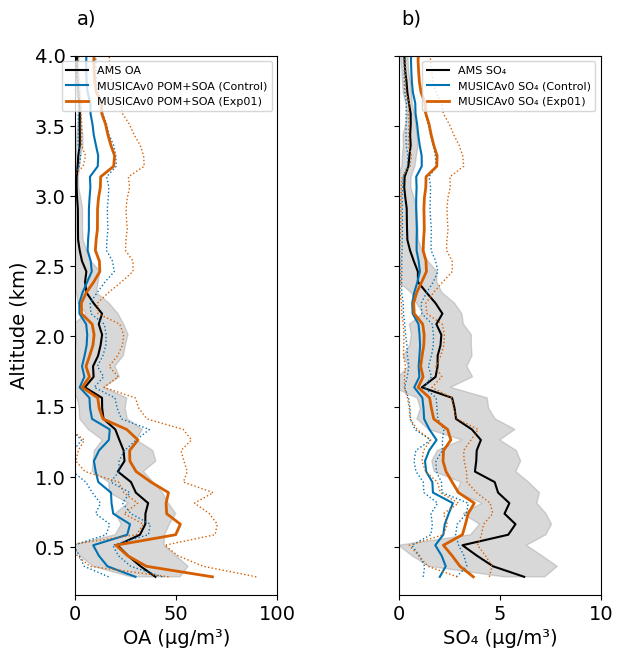

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 7))
gs = gridspec.GridSpec(
    nrows=1, ncols=4,
    width_ratios=[3, 1, 3, 1],
    wspace=0.2
)

xlabels = ['OA (µg/m³)', 'SO₄ (µg/m³)']
xlims = [100, 10]
xlimcounts = [1000, 1000]
titles = ['Organic Aerosol (OA)', 'Sulfate (SO₄)']
legend_labels = [
    ('AMS OA', 'MUSICAv0 POM+SOA'),
    ('AMS SO₄', 'MUSICAv0 SO₄')
]

datasets = [
    (grouped_mean_oa_ams, grouped_std_oa_ams,
     grouped_mean_oa_mod, grouped_std_oa_mod),

    (grouped_mean_so4_ams, grouped_std_so4_ams,
     grouped_mean_so4_mod, grouped_std_so4_mod)
]

exp01_datasets = [
    (grouped_mean_oa_ams_exp01, grouped_std_oa_ams_exp01,
     grouped_mean_oa_mod_exp01, grouped_std_oa_mod_exp01),

    (grouped_mean_so4_ams_exp01, grouped_std_so4_ams_exp01,
     grouped_mean_so4_mod_exp01, grouped_std_so4_mod_exp01)
]

counts_obs = [grouped_count_oa_ams, grouped_count_so4_ams]
counts_mod = [grouped_count_oa_mod, grouped_count_so4_mod]

for i, ((mean_obs, std_obs, mean_mod, std_mod),
        (exp01_mean_obs, exp01_std_obs, exp01_mean_mod, exp01_std_mod),
        (label_obs, label_mod), xlabel, xlim, xlimcount) in enumerate(
        zip(datasets, exp01_datasets, legend_labels, xlabels, xlims, xlimcounts)):

    # --- filter altitude bins >= 0.25 km ---
    mask = bin_centers >= 0.25

    mean_obs = mean_obs[mask]
    std_obs  = std_obs[mask]
    mean_mod = mean_mod[mask]
    std_mod  = std_mod[mask]

    exp01_mean_mod = exp01_mean_mod[mask]
    exp01_std_mod  = exp01_std_mod[mask]

    bin_centers_filtered = bin_centers[mask]

    # --- main profile subplot ---
    ax = fig.add_subplot(gs[0, 2*i])

    ax.plot(mean_obs.values, bin_centers_filtered, color='k', label=label_obs)
    ax.fill_betweenx(bin_centers_filtered,
                     mean_obs.values - std_obs.values,
                     mean_obs.values + std_obs.values,
                     color='gray', alpha=0.3)

    ax.plot(mean_mod.values, bin_centers_filtered, color='#0072B2',
            label=f'{label_mod} (Control)')
    ax.plot(mean_mod.values - std_mod.values, bin_centers_filtered,
            color='#0072B2', linestyle=':', linewidth=1)
    ax.plot(mean_mod.values + std_mod.values, bin_centers_filtered,
            color='#0072B2', linestyle=':', linewidth=1)

    ax.plot(exp01_mean_mod.values, bin_centers_filtered,
            color='#D55E00', linewidth=2,
            label=f'{label_mod} (Exp01)')
    ax.plot(exp01_mean_mod.values - exp01_std_mod.values, bin_centers_filtered,
            color='#D55E00', linestyle=':', linewidth=1)
    ax.plot(exp01_mean_mod.values + exp01_std_mod.values, bin_centers_filtered,
            color='#D55E00', linestyle=':', linewidth=1)

    ax.text(0.01, 1.05, f'{chr(97+i)})', transform=ax.transAxes,
            fontsize=14, va='bottom', ha='left')

    ax.set_ylim(0.16, 4)
    ax.set_xlim(0, xlim)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.legend(loc='upper right', fontsize=8)

    if i == 0:
        ax.set_ylabel('Altitude (km)', fontsize=14)
    else:
        ax.tick_params(axis='y', labelleft=False)
plt.show()